<div style="background:#1f77b4; color:#fff; padding:10px 18px; border-radius:8px;">
    Healthcare_Dataset analysis
</div>

In [1]:
# Read the file 'healthcare_dataset.csv'
import pandas as pd
df= pd.read_csv('healthcare_dataset.csv')
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


    ✅ Patient Demographics
      1) What is the age distribution of patients?
      2) How many male vs female patients are there?
      3) Which blood types are most common?
      4) What is the average age per medical condition?

**1. Age distribution of patients**

In [10]:
df['Age'].describe()

count    55500.000000
mean        51.539459
std         19.602454
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64

**2. Male VS Female patients**

In [15]:
df.groupby(by = 'Gender', as_index = False).agg({'Name':'count'}).rename(columns={'Name':'Total_Count'})

,Gender,Total_Count
0,Female,27726
1,Male,27774


**3. Blood types that are most common** 

In [5]:
df.groupby(by = 'Blood Type', as_index = False).agg({'Name':'count'}).rename(columns={'Name':'Total_Count'}).sort_values(by = 'Total_Count', ascending = False)

,Blood Type,Total_Count
1,A-,6969
0,A+,6956
2,AB+,6947
3,AB-,6945
4,B+,6945
5,B-,6944
6,O+,6917
7,O-,6877


**4. Average age per medical condition**

In [21]:
df.groupby(by = 'Medical Condition', as_index= False)['Age'].mean().round(2).rename(columns={'Age':'Avg_age'})

,Medical Condition,Avg_age
0,Arthritis,51.57
1,Asthma,51.58
2,Cancer,51.56
3,Diabetes,51.55
4,Hypertension,51.74
5,Obesity,51.24


    ✅ Medical Condition Insights
       5) Which medical conditions are most frequent?
       6) What is the average billing amount per medical condition?
       7) Which conditions lead to the longest hospital stays?

**5. Top 3 medical conditions which are frequent**

In [25]:
df.groupby(by = 'Medical Condition', as_index= False)['Age'].count().round(2).rename(columns={'Age':'Total_count'}).sort_values(by='Total_count', ascending = False).head(3)

,Medical Condition,Total_count
0,Arthritis,9308
3,Diabetes,9304
4,Hypertension,9245


**6. Average billing amount per medical condition**

In [8]:
df.groupby(by = 'Medical Condition', as_index= False)['Billing Amount'].mean().rename(columns={'Billing Amount':'Avg_Billing_amnt'})

,Medical Condition,Avg_Billing_amnt
0,Arthritis,25497.327056
1,Asthma,25635.249359
2,Cancer,25161.792707
3,Diabetes,25638.405577
4,Hypertension,25497.095761
5,Obesity,25805.971259


**7. Conditions that lead to the longest hospital stays**

In [3]:
# Convert object to datetime datatype

df['Date of Admission'] = pd.to_datetime(df['Date of Admission'], format = '%Y-%m-%d')
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'], format = '%Y-%m-%d')

In [22]:
# Add new column 'Stay_Days'

df['stay_days'] = (df['Date of Admission'] - df['Discharge Date']).abs().dt.days
df.groupby(by='Medical Condition', as_index = False).agg({'stay_days':'mean'}).rename(columns={'stay_days':'Avg_Stay_Days'}).sort_values('Avg_Stay_Days', ascending = False)

,Medical Condition,Avg_Stay_Days
1,Asthma,15.696570
0,Arthritis,15.517404
2,Cancer,15.495827
5,Obesity,15.464305
4,Hypertension,15.458626
3,Diabetes,15.422936


    ✅Admission & Discharge Analysis
      6) Which admission type (Urgent, Emergency, Elective) is most common?
      7) What is the average length of stay by:
           Medical condition
           Hospital
           Doctor
      8) How many patients were admitted in each year?

**6.Most common admission type**

In [30]:
df.groupby(by = 'Admission Type', as_index = False)['Name'].count().rename(columns = {'Name':'Total_count'}).sort_values(by = 'Total_count', ascending = False).head(1)

,Admission Type,Total_count
0,Elective,18655


**7. Average length of stay by: (Medical condition, Hospital, Doctor)**

In [23]:
df.groupby(by=['Medical Condition','Hospital','Doctor'], as_index = False).agg({'stay_days':'mean'}).rename(columns={'stay_days':'Avg_Stay_Days'}).sort_values('Avg_Stay_Days', ascending = False)

,Medical Condition,Hospital,Doctor,Avg_Stay_Days
20687,Cancer,Ltd Orr,Chase Rivers,30.0
10604,Asthma,Group Murphy,Jesse Hamilton,30.0
18568,Cancer,Gordon-Hunt,Brittany Perry,30.0
40401,Hypertension,Ward-Reid,Edwin Edwards,30.0
10626,Asthma,Group Reyes,Rebecca Ramos,30.0
...,...,...,...,...
14178,Asthma,Rodriguez and Sons,Christina Green,1.0
32257,Diabetes,"Williams Palmer Miller, and",Megan Ibarra,1.0
14219,Asthma,"Romero Calderon and Martin,",Michael James,1.0
32240,Diabetes,"Williams Duffy, Gray and",Bryan Bowers,1.0


**8. Patients admitted each year**

In [24]:
df.head(3)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,stay_days
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15


In [4]:
# Create a 'Year' column

df['Year'] = df['Date of Admission'].dt.year

In [14]:
df_patients = df.groupby(by = 'Year', as_index = False).agg({'Name':'count'}).rename(columns={'Name':'Total_count'})

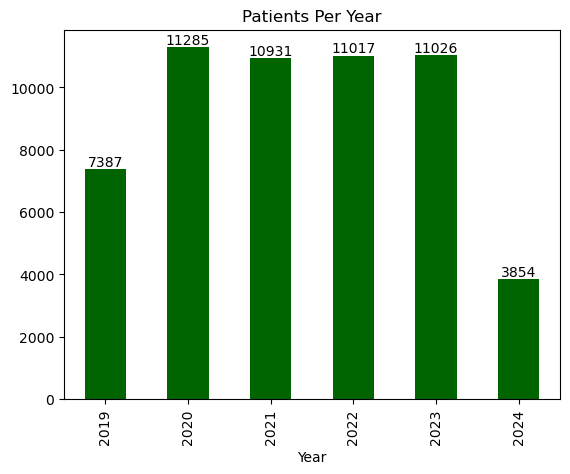

In [15]:
df_patients = df_patients.plot(kind='bar', x='Year', y='Total_count',  color='darkgreen', title = 'Patients Per Year')
df_patients.legend().remove()

for container in df_patients.containers:
    df_patients.bar_label(container, fmt='%d')

    ✅ Hospital & Doctor Performance
       9) Which doctors handle the most patients?
       10) What are the top hospitals by:
             Number of patients
             Average treatment cost

**9. Doctors that handle the most patients**

In [18]:
new_df = df['Doctor'].value_counts().to_frame().reset_index().rename(columns={'count':'Total_patients'}).sort_values(by='Total_patients', ascending = False).head(5)

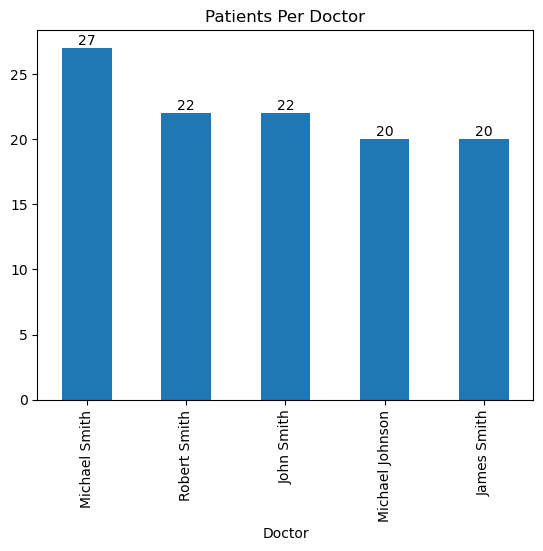

In [20]:
new_df = new_df.plot(kind = 'bar', x='Doctor', y='Total_patients', title = 'Patients Per Doctor')
new_df.legend().remove()

for container in new_df.containers:
    new_df.bar_label(container, fmt = '%d')

**10. What are the top hospitals by:
        Number of patients
        , Average treatment cost**

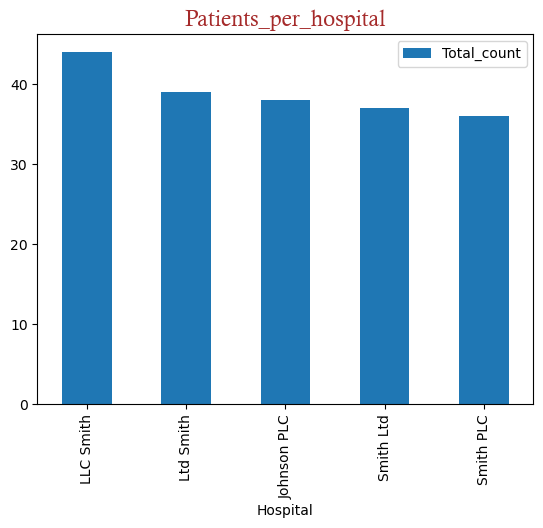

In [37]:
df_hospital = df['Hospital'].value_counts().to_frame().reset_index().rename(columns={'count':'Total_count'}).sort_values('Total_count', ascending=False).head(5)

import matplotlib.pyplot as plt

# Create the bar plot and get the axes object
df_hospital = df_hospital.plot(kind='bar', x='Hospital', y='Total_count')

# Set the title using ax.set_title()
df_hospital.set_title('Patients_per_hospital')

# Optional: Customize title properties
df_hospital.set_title('Patients_per_hospital', fontsize=16, fontweight='light', color='brown', fontfamily='Calisto MT')

plt.show()

In [59]:
df_avg_billing_amnt = df.groupby('Hospital', as_index=False).agg(Avg_Billing_Amnt=('Billing Amount','mean')).sort_values('Avg_Billing_Amnt', ascending= False).head(5)
df_avg_billing_amnt

,Hospital,Avg_Billing_Amnt
12427,Hernandez-Morton,52373.032374
32412,Walker-Garcia,52170.036854
27346,Ruiz-Anthony,52154.237722
9288,George-Gonzalez,52102.240889
26661,Rocha-Carter,52092.669896


In [46]:
df['Hospital'].nunique()

39876

    ✅ Medication & Test Results
    11. Which medications are most commonly prescribed?
    12. What percentage of test results are Normal vs Abnormal?

**11. medications are most commonly prescribed**

In [63]:
df['Medication'].value_counts().to_frame().reset_index()

,Medication,count
0,Lipitor,11140
1,Ibuprofen,11127
2,Aspirin,11094
3,Paracetamol,11071
4,Penicillin,11068


**12. percentage of test results are Normal vs Abnormal**

In [66]:
df['Test Results'].value_counts(normalize=True)*100

Test Results
Abnormal        33.562162
Normal          33.363964
Inconclusive    33.073874
Name: proportion, dtype: float64